# Лабораторная работа 3
## Эргодическая марковская цепь

Здор Матвей 342951

### 1. Описание цепи

Модель погоды с 4 состояниями:
- `S1` — солнечно
- `S2` — облачно
- `S3` — дождливо
- `S4` — ветрено

Матрица переходов:

$$
P = \begin{pmatrix}
0.10 & 0.40 & 0.30 & 0.20 \\
0.20 & 0.20 & 0.40 & 0.20 \\
0.25 & 0.25 & 0.20 & 0.30 \\
0.30 & 0.20 & 0.20 & 0.30
\end{pmatrix}
$$

Все вероятности положительные, значит цепь неприводимая. Также можно остаться в каждом состоянии, значит цепь апериодическая. Поэтому она эргодическая.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=6, suppress=True)

states = ['S1: солнечно', 'S2: облачно', 'S3: дождливо', 'S4: ветрено']
P = np.array([
    [0.10, 0.40, 0.30, 0.20],
    [0.20, 0.20, 0.40, 0.20],
    [0.25, 0.25, 0.20, 0.30],
    [0.30, 0.20, 0.20, 0.30],
], dtype=float)

epsilon = 1e-8

print('Матрица переходных вероятностей P:')
print(P)
print('\nПроверка сумм по строкам:')
print(P.sum(axis=1))


Матрица переходных вероятностей P:
[[0.1  0.4  0.3  0.2 ]
 [0.2  0.2  0.4  0.2 ]
 [0.25 0.25 0.2  0.3 ]
 [0.3  0.2  0.2  0.3 ]]

Проверка сумм по строкам:
[1. 1. 1. 1.]


### 2. Диаграмма переходов


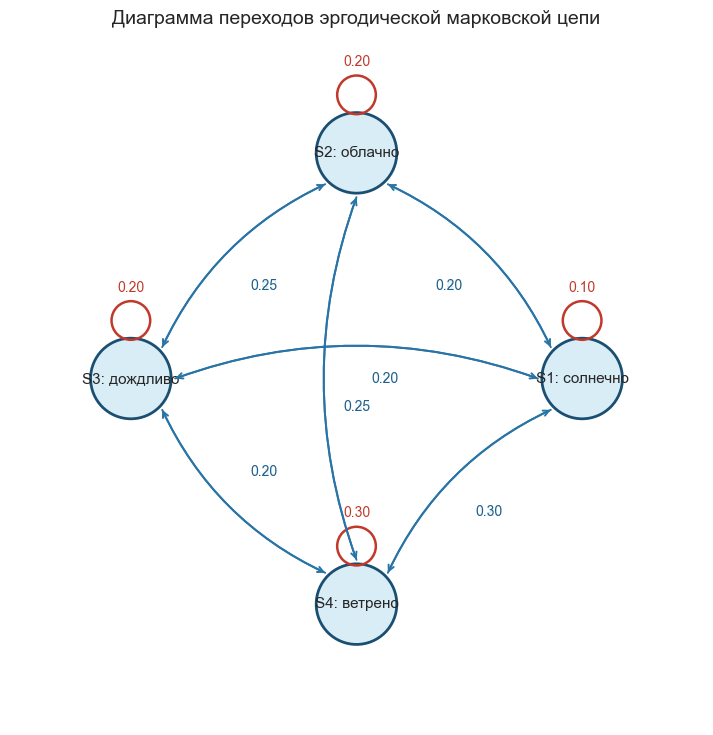

In [2]:
fig, ax = plt.subplots(figsize=(9, 9))
angles = np.linspace(0, 2 * np.pi, len(states), endpoint=False)
radius = 2.8
positions = {
    state: np.array([radius * np.cos(angle), radius * np.sin(angle)])
    for state, angle in zip(states, angles)
}

for state, (x, y) in positions.items():
    circle = plt.Circle((x, y), 0.5, color='#d9edf7', ec='#1b4f72', lw=2)
    ax.add_patch(circle)
    ax.text(x, y, state, ha='center', va='center', fontsize=11)

for i, state_from in enumerate(states):
    for j, state_to in enumerate(states):
        prob = P[i, j]
        start = positions[state_from]
        end = positions[state_to]
        if i == j:
            loop = plt.Circle((start[0], start[1] + 0.72), 0.24, fill=False, ec='#c0392b', lw=1.8)
            ax.add_patch(loop)
            ax.text(start[0], start[1] + 1.08, f'{prob:.2f}', color='#c0392b', ha='center', fontsize=10)
        else:
            direction = end - start
            norm = np.linalg.norm(direction)
            unit = direction / norm
            start_arrow = start + unit * 0.55
            end_arrow = end - unit * 0.55
            rad = 0.18 if i < j else -0.18
            ax.annotate(
                '',
                xy=end_arrow,
                xytext=start_arrow,
                arrowprops=dict(
                    arrowstyle='->',
                    color='#2874a6',
                    lw=1.4,
                    shrinkA=0,
                    shrinkB=0,
                    connectionstyle=f'arc3,rad={rad}'
                )
            )
            midpoint = (start_arrow + end_arrow) / 2
            normal = np.array([-unit[1], unit[0]])
            label_pos = midpoint + normal * (0.35 if rad > 0 else -0.35)
            ax.text(
                label_pos[0], label_pos[1], f'{prob:.2f}', color='#1f618d', fontsize=10,
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.85)
            )

ax.set_title('Диаграмма переходов эргодической марковской цепи', fontsize=14)
ax.set_xlim(-4.3, 4.3)
ax.set_ylim(-4.3, 4.3)
ax.set_aspect('equal')
ax.axis('off')
plt.show()


### 3. Пошаговое моделирование

Проверю несколько разных начальных векторов. На каждом шаге считаю по формуле

Считаю шаги, пока отклонение между старым и новым вектором не станет меньше $\varepsilon$.


In [3]:
initial_vectors = {
    'Старт 1: [1, 0, 0, 0]': np.array([1.0, 0.0, 0.0, 0.0]),
    'Старт 2: [0, 1, 0, 0]': np.array([0.0, 1.0, 0.0, 0.0]),
    'Старт 3: [0.4, 0.1, 0.3, 0.2]': np.array([0.4, 0.1, 0.3, 0.2]),
    'Старт 4: [0.25, 0.25, 0.25, 0.25]': np.array([0.25, 0.25, 0.25, 0.25]),
}

def simulate_markov_chain(initial_vector, transition_matrix, eps=1e-8, max_steps=1000):
    old_vector = np.array(initial_vector, dtype=float)
    vector_history = [old_vector.copy()]
    rmse_history = []

    for step in range(1, max_steps + 1):
        new_vector = old_vector @ transition_matrix
        rmse = np.sqrt(np.mean((new_vector - old_vector) ** 2))
        rmse_history.append(rmse)
        vector_history.append(new_vector.copy())
        old_vector = new_vector
        if rmse < eps:
            return {
                'steps': step,
                'final_vector': new_vector,
                'vector_history': np.array(vector_history),
                'rmse_history': np.array(rmse_history),
            }

    raise RuntimeError('Достигнуто максимальное число шагов без сходимости.')

results = {
    name: simulate_markov_chain(initial_vector, P, eps=epsilon)
    for name, initial_vector in initial_vectors.items()
}

for name, result in results.items():
    print(name)
    print(f"  число шагов до сходимости: {result['steps']}")
    print(f"  предельный вектор: {result['final_vector']}")
    print()


Старт 1: [1, 0, 0, 0]
  число шагов до сходимости: 10
  предельный вектор: [0.217195 0.257096 0.273139 0.252571]

Старт 2: [0, 1, 0, 0]
  число шагов до сходимости: 9
  предельный вектор: [0.217195 0.257096 0.273139 0.252571]

Старт 3: [0.4, 0.1, 0.3, 0.2]
  число шагов до сходимости: 9
  предельный вектор: [0.217195 0.257096 0.273139 0.252571]

Старт 4: [0.25, 0.25, 0.25, 0.25]
  число шагов до сходимости: 8
  предельный вектор: [0.217195 0.257096 0.273139 0.252571]



### 4. Графики изменения компонентов векторов и среднеквадратического отклонения


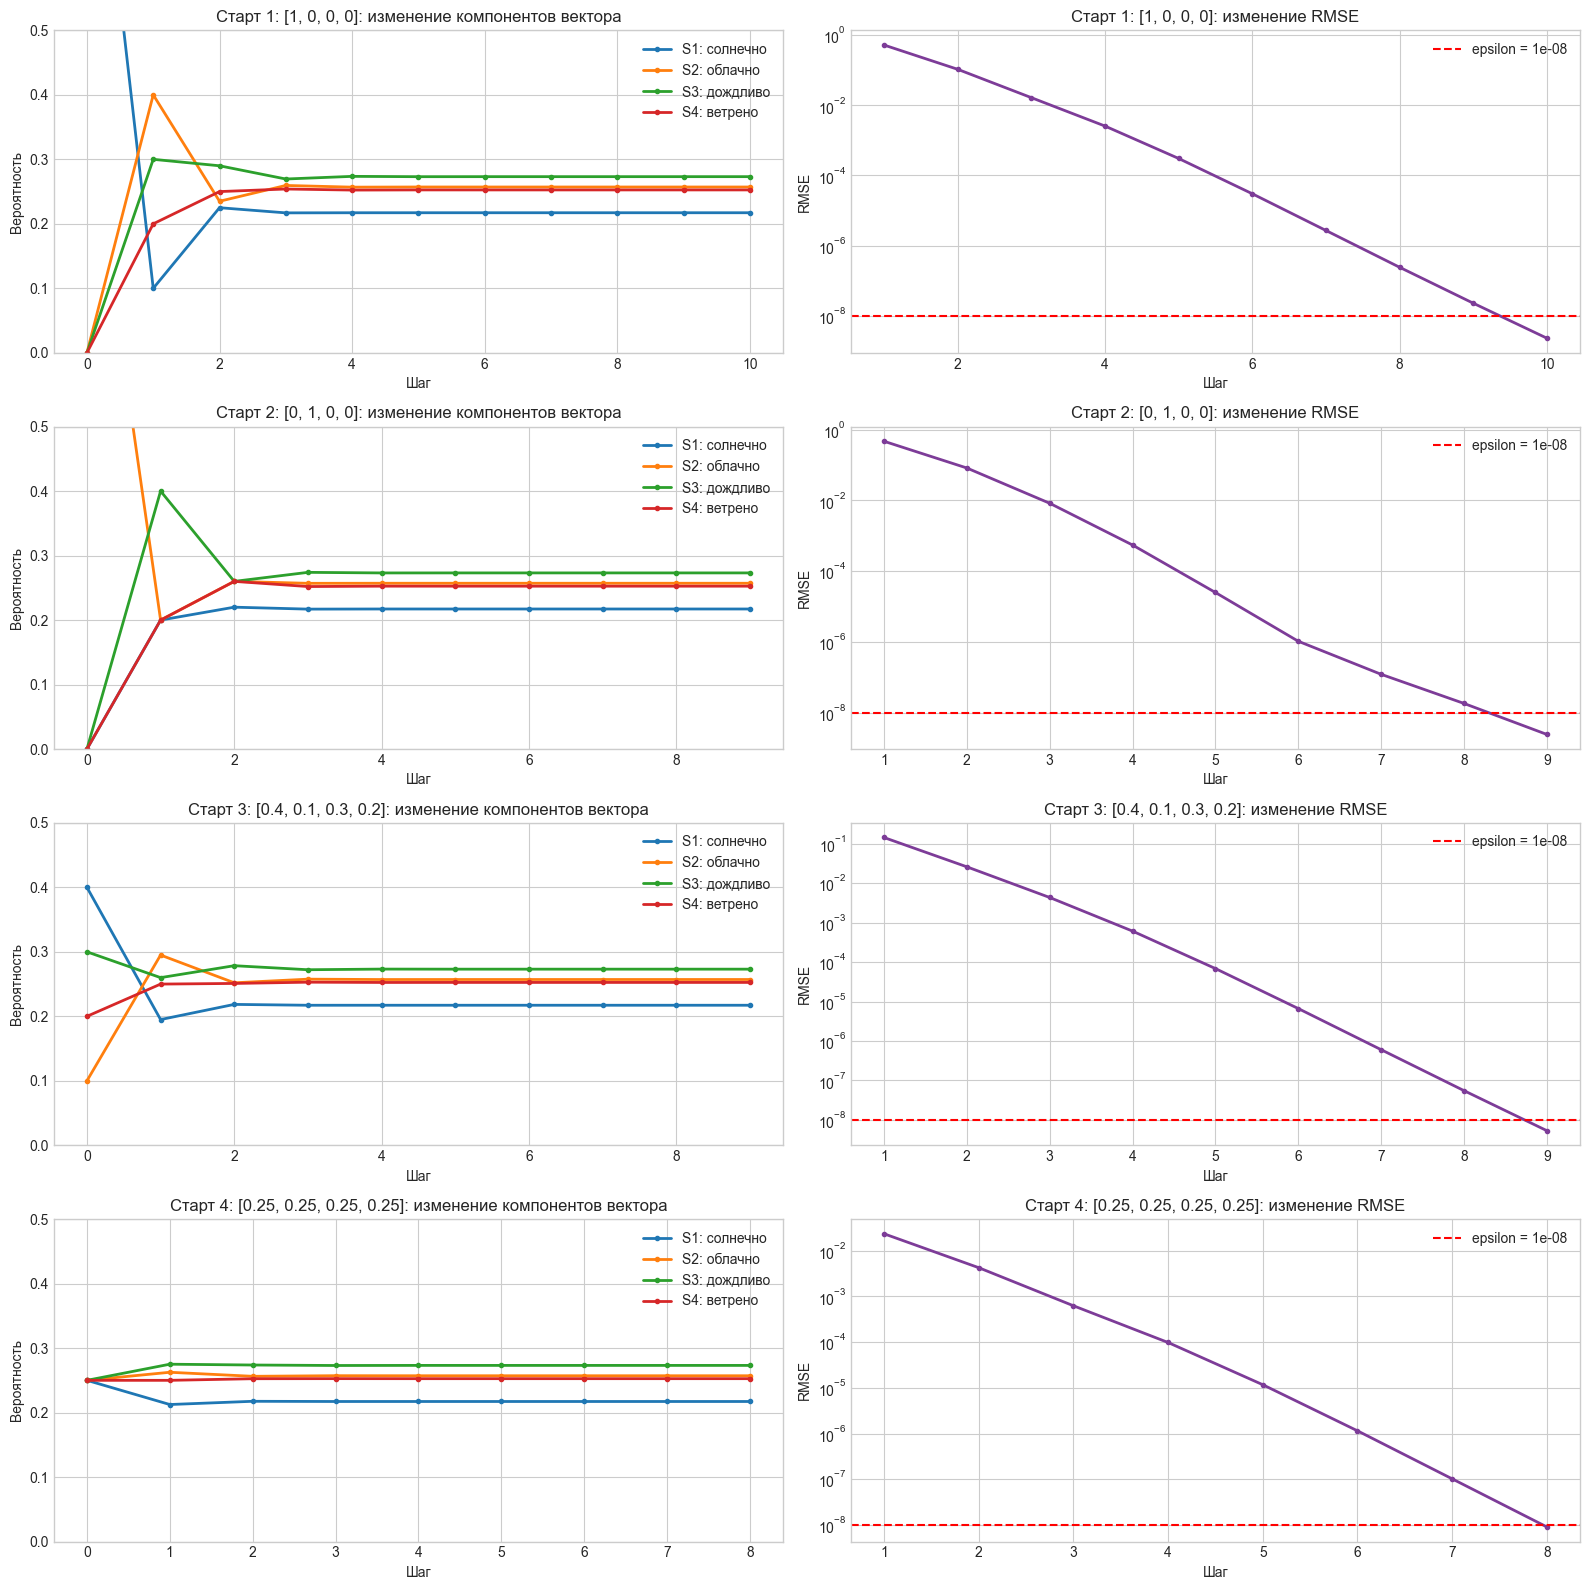

In [4]:
fig, axes = plt.subplots(len(results), 2, figsize=(16, 4 * len(results)))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

if len(results) == 1:
    axes = np.array([axes])

for row, (name, result) in enumerate(results.items()):
    vectors = result['vector_history']
    rmse = result['rmse_history']
    steps = np.arange(vectors.shape[0])

    ax_left = axes[row, 0]
    for idx, state in enumerate(states):
        ax_left.plot(
            steps, vectors[:, idx], marker='o', markersize=3,
            linewidth=2, color=colors[idx], label=state
        )
    ax_left.set_title(f'{name}: изменение компонентов вектора')
    ax_left.set_xlabel('Шаг')
    ax_left.set_ylabel('Вероятность')
    ax_left.set_ylim(0, 0.5)
    ax_left.legend()

    ax_right = axes[row, 1]
    ax_right.plot(
        np.arange(1, len(rmse) + 1), rmse, marker='o', markersize=3,
        linewidth=2, color='#7d3c98'
    )
    ax_right.set_title(f'{name}: изменение RMSE')
    ax_right.set_xlabel('Шаг')
    ax_right.set_ylabel('RMSE')
    ax_right.set_yscale('log')
    ax_right.axhline(epsilon, color='red', linestyle='--', label=f'epsilon = {epsilon}')
    ax_right.legend()

plt.tight_layout()
plt.show()


### 5. Аналитическое решение

Стационарный вектор $\pi$ должен удовлетворять системе



In [5]:
A = P.T - np.eye(len(states))
A[-1] = np.ones(len(states))
b = np.zeros(len(states))
b[-1] = 1

pi = np.linalg.solve(A, b)

print('Стационарное распределение, найденное аналитически:')
print(pi)
print('Сумма компонент:', pi.sum())


Стационарное распределение, найденное аналитически:
[0.217195 0.257096 0.273139 0.252571]
Сумма компонент: 1.0


### 6. Сравнение результатов


In [6]:
for name, result in results.items():
    final_vector = result['final_vector']
    difference = np.abs(final_vector - pi)
    print(name)
    print('  финальный вектор моделирования: ', final_vector)
    print('  аналитический стационарный вектор:', pi)
    print('  модуль разности:                ', difference)
    print('  максимальное отклонение:        ', difference.max())
    print()


Старт 1: [1, 0, 0, 0]
  финальный вектор моделирования:  [0.217195 0.257096 0.273139 0.252571]
  аналитический стационарный вектор: [0.217195 0.257096 0.273139 0.252571]
  модуль разности:                 [0. 0. 0. 0.]
  максимальное отклонение:         3.5144759324978736e-10

Старт 2: [0, 1, 0, 0]
  финальный вектор моделирования:  [0.217195 0.257096 0.273139 0.252571]
  аналитический стационарный вектор: [0.217195 0.257096 0.273139 0.252571]
  модуль разности:                 [0. 0. 0. 0.]
  максимальное отклонение:         4.2019754342703663e-10

Старт 3: [0.4, 0.1, 0.3, 0.2]
  финальный вектор моделирования:  [0.217195 0.257096 0.273139 0.252571]
  аналитический стационарный вектор: [0.217195 0.257096 0.273139 0.252571]
  модуль разности:                 [0. 0. 0. 0.]
  максимальное отклонение:         7.923023903622095e-10

Старт 4: [0.25, 0.25, 0.25, 0.25]
  финальный вектор моделирования:  [0.217195 0.257096 0.273139 0.252571]
  аналитический стационарный вектор: [0.217195 0.257